## Fractal Generation and Box‑Counting Dimension
### Author: Łukasz Grzegrzółka

This notebook contains my solutions to the first assignment from the course Computer Simulations in Physics at the Faculty of Physics, University of Warsaw.
The goal of the exercise was to implement Iterated Function Systems (IFS), generate several classical fractals, and estimate their fractal dimensions using the box‑counting method.

### Section 1 - Generating Fractals Using Iterated Function Systems

In this part of the assignment, the goal was to implement the Iterated Function System (IFS) algorithm and use it to generate several classical fractals. An IFS is defined as a collection of affine transformations, each of which maps a point ((x, y)) to a new point according to a linear rule with an added translation. At every iteration, one of these transformations is selected randomly with a prescribed probability, and the process is repeated many times. Starting from the initial point ((0, 0)), the repeated application of these randomly chosen contractions causes the trajectory to converge to a characteristic geometric structure known as the fractal attractor.

In the notebook, I implemented four different fractals: the Sierpiński triangle, Barnsley’s fern, the fractal dragon, and the Lévy C curve. Each of them is defined by its own set of affine maps and probability weights. For every fractal, the algorithm performs (N = 100000) iterations, storing the successive coordinates in arrays and finally visualizing the resulting point cloud. The plotting function removes axes and uses a black background to highlight the self‑similar structure of the generated shapes. The obtained images reproduce the expected geometry of each fractal: the triangular pattern of the Sierpiński gasket, the natural leaf‑like structure of the fern, the characteristic folding of the dragon curve, and the recursive zig‑zag pattern of the Lévy curve.

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def lin(x, a, b):
    return a*x + b

def plot_fractal(x, y):
    fig, ax = plt.subplots()
    ax.set_facecolor('black')

    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.tick_params(axis='both', which='both', length=0)
    plt.scatter(x, y, s=1, marker="o", lw=0, c="green")

    ax.set_xticks([])
    ax.set_yticks([])
    return fig, ax


fractals = {"sierpinski": {"prob": np.array([1/3, 1/3, 1/3]),
                           "m": np.array([[0.5, 0, 0, 0.5, 0.25, np.sqrt(3.) / 4],
                                          [0.5, 0, 0, 0.5, 0, 0],
                                          [0.5, 0, 0, 0.5, 0.5, 0]])},
            "fern": {"prob": np.array([0.02, 0.09, 0.10, 0.79]),
                     "m": np.array([[0.001, 0.0, 0.0, 0.16, 0.0, 0.0],
                                    [-0.15, 0.28, 0.26, 0.24, 0.0, 0.44],
                                    [0.2, -0.26, 0.23, 0.22, 0.0, 1.6],
                                    [0.85, 0.04, -0.04, 0.85, 0.0, 1.6]])},
            "dragon": {"prob": np.array([0.787473, 0.212527]),
                       "m": np.array([[0.824074, 0.281482, -0.212346, 0.864198, -1.882290, -0.110607],
                                      [0.088272, 0.520988, -0.463889, -0.377778, 0.785360, 8.095795]])},
            "levy": {"prob": np.array([1/2, 1/2]),
                     "m": np.array([[0.5, -0.5, 0.5, 0.5, 0.0, 0.0],
                                    [0.5, 0.5, -0.5, 0.5, 0.5, 0.5]])
                     }}


### Sierpiński triangle

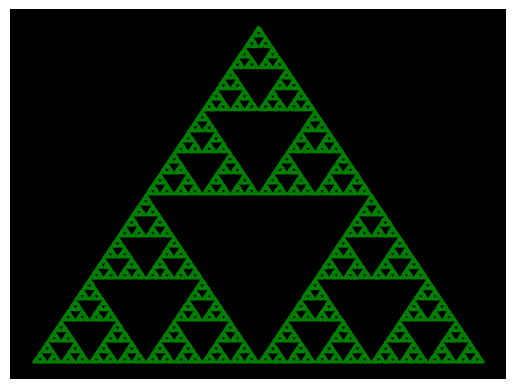

In [15]:
ps = fractals["sierpinski"]["prob"]
m = fractals["sierpinski"]["m"]

N = 100000
x = 0
y = 0
X = np.array([x])
Y = np.array([y])
ns = np.random.choice(3, N-1, p=ps)

for i in range(N-1):
    n = ns[i]
    xn = m[n][0]*x + m[n][1]*y + m[n][4]
    yn = m[n][2]*x + m[n][3]*y + m[n][5]
    x=xn
    y=yn
    X = np.append(X, x)
    Y = np.append(Y, y)

fig, ax = plot_fractal(X, Y)
plt.show()

### Barnsley’s fern

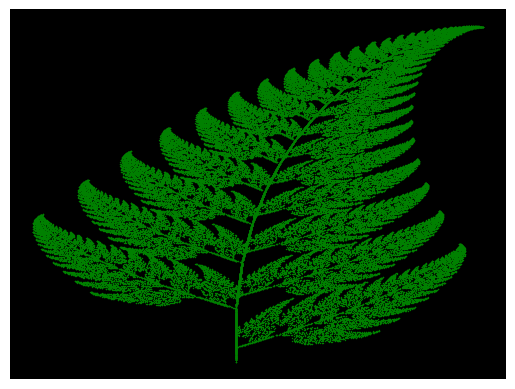

In [16]:
pf = fractals["fern"]["prob"]
mf = fractals["fern"]["m"]
nf = np.random.choice(4, N-1, p=pf)
x = 0
y = 0
X2 = np.array([x])
Y2 = np.array([y])

for i in range(N-1):
    n = nf[i]
    xn = mf[n][0]*x + mf[n][1]*y + mf[n][4]
    yn = mf[n][2]*x + mf[n][3]*y + mf[n][5]
    x=xn
    y=yn
    X2 = np.append(X2, x)
    Y2 = np.append(Y2, y)

fig, ax = plot_fractal(X2, Y2)
plt.show()

### Fractal dragon

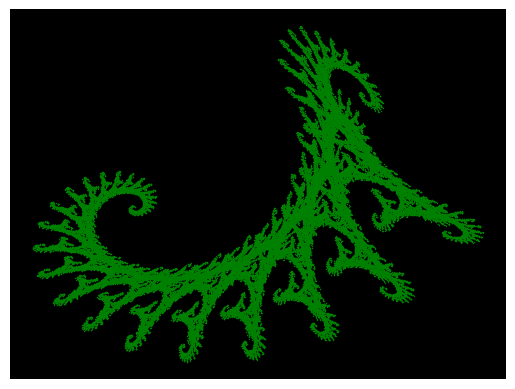

In [17]:
pd = fractals["dragon"]["prob"]
md = fractals["dragon"]["m"]
nd = np.random.choice(2, N-1, p=pd)
x = 0
y = 0
X3 = np.array([x])
Y3 = np.array([y])

for i in range(N-1):
    n = nd[i]
    xn = md[n][0]*x + md[n][1]*y + md[n][4]
    yn = md[n][2]*x + md[n][3]*y + md[n][5]
    x=xn
    y=yn
    X3 = np.append(X3, x)
    Y3 = np.append(Y3, y)

fig, ax = plot_fractal(X3, Y3)
plt.show()

### Lévy C curve

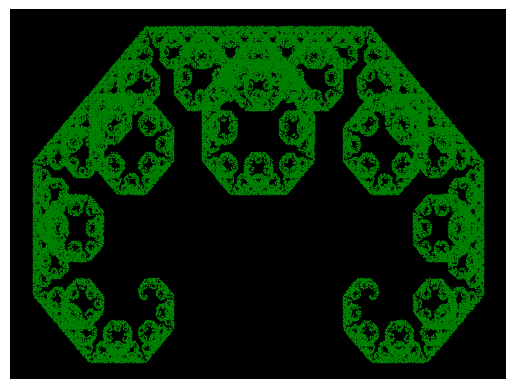

In [18]:
pl = fractals["levy"]["prob"]
ml = fractals["levy"]["m"]
nl = np.random.choice(2, N-1, p=pl)
x = 0
y = 0
X4 = np.array([x])
Y4 = np.array([y])

for i in range(N-1):
    n = nl[i]
    xn = ml[n][0]*x + ml[n][1]*y + ml[n][4]
    yn = ml[n][2]*x + ml[n][3]*y + ml[n][5]
    x=xn
    y=yn
    X4 = np.append(X4, x)
    Y4 = np.append(Y4, y)


fig, ax = plot_fractal(X4, Y4)
plt.show()

### Section 2 - Estimating Fractal Dimension via Box‑Counting

The second part of the task focuses on determining the fractal dimension of the generated structures using the box‑counting method. The idea is to cover the fractal with a square grid of increasing resolution and count how many boxes contain at least one point. For a grid of size $2^r \times 2^r$, the number of occupied boxes is denoted by $N_r$. For self‑similar fractals, this quantity follows a power‑law scaling of the form $N_r \sim (2^r)^{D_f}$, where $D_f$ is the fractal dimension. Taking the logarithm of both sides yields a linear relation between $\ln N_r$ and $r$, with slope equal to $D_f \ln 2$. In practice, the histogram‑based function computes $N_r$ by binning all points into a grid of $2^r$ bins along each axis and counting the non‑empty cells.

After computing $N_r$ for a range of values of $r$, the notebook plots $\ln N_r$ as a function of $r$ and performs a linear fit in the region where the scaling is approximately linear. The flattening of the curves at large $r$ is expected, because the finite number of points limits the effective resolution: once the grid becomes too fine, many boxes remain empty and the scaling breaks down. Using the linear region, the fitted slope is divided by $\ln 2$ to obtain the estimated fractal dimension.

In [19]:
def N(X, Y, r):
    H = np.histogram2d(X, Y, bins=2**(r))[0]
    Nr = np.count_nonzero(H)
    return Nr

r = np.arange(13)

squares_sierpinski = np.array([])
for i in r:
    squares_sierpinski = np.append(squares_sierpinski, N(X, Y, i))

squares_fern = np.array([])
for i in r:
    squares_fern = np.append(squares_fern, N(X2, Y2, i))

squares_dragon = np.array([])
for i in r:
    squares_dragon = np.append(squares_dragon, N(X3, Y3, i))

squares_levy = np.array([])
for i in r:
    squares_levy = np.append(squares_levy, N(X4, Y4, i))


1.598039087980383


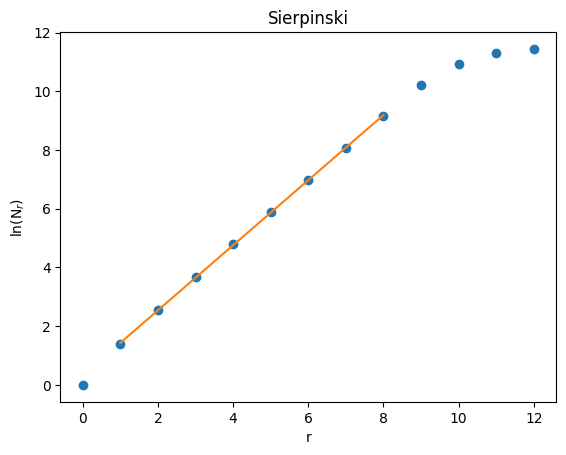

In [20]:
par_sierpinski, cov_sierpinski = curve_fit(lin, r[1:9], np.log(squares_sierpinski[1:9]))
D_sierpinski = par_sierpinski[0]/np.log(2)
print(D_sierpinski)

#"""
plt.plot(r, np.log(squares_sierpinski), "o")
plt.plot(r[1:9], lin(r[1:9], *par_sierpinski))
plt.title("Sierpinski")
plt.xlabel("r")
plt.ylabel("ln(N$_{r}$)")
plt.show()

1.7932006488991452


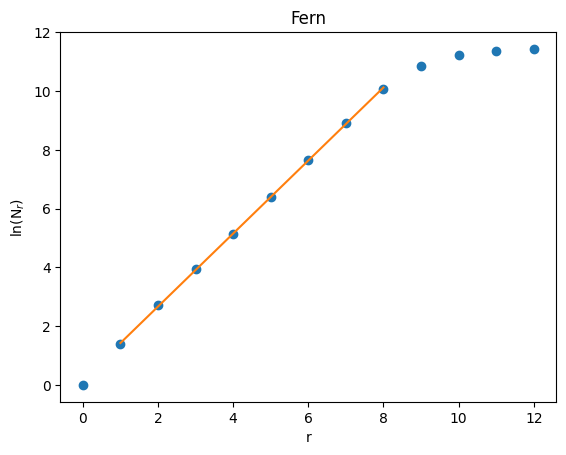

In [21]:
par_fern, cov_fern = curve_fit(lin, r[1:9], np.log(squares_fern[1:9]))
D_fern = par_fern[0]/np.log(2)
print(D_fern)

plt.plot(r, np.log(squares_fern), "o")
plt.plot(r[1:9], lin(r[1:9], *par_fern))
plt.title("Fern")
plt.xlabel("r")
plt.ylabel("ln(N$_{r}$)")
plt.show()

1.6664882715262843


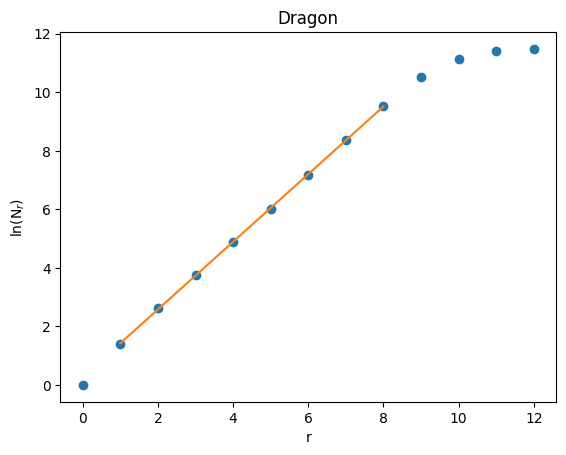

In [22]:
par_dragon, cov_dragon = curve_fit(lin, r[1:9], np.log(squares_dragon[1:9]))
D_dragon = par_dragon[0]/np.log(2)
print(D_dragon)

plt.plot(r, np.log(squares_dragon), "o")
plt.plot(r[1:9], lin(r[1:9], *par_dragon))
plt.title("Dragon")
plt.xlabel("r")
plt.ylabel("ln(N$_{r}$)")
plt.show()


1.7855937442319887


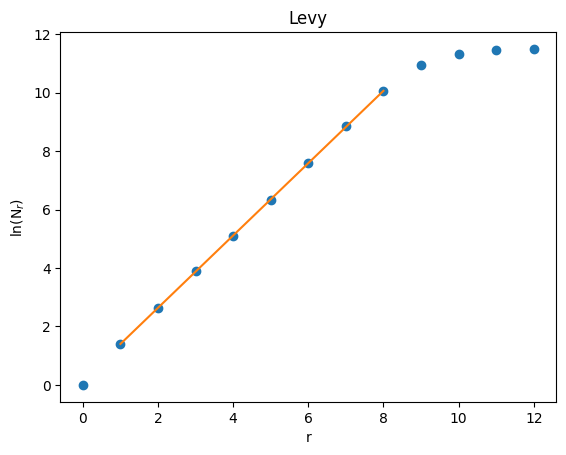

In [23]:
par_levy, cov_levy = curve_fit(lin, r[1:9], np.log(squares_levy[1:9]))
D_levy = par_levy[0]/np.log(2)
print(D_levy)

plt.plot(r, np.log(squares_levy), "o")
plt.plot(r[1:9], lin(r[1:9], *par_levy))
plt.title("Levy")
plt.xlabel("r")
plt.ylabel("ln(N$_{r}$)")
plt.show()


In [24]:
print(np.sqrt(np.diag(cov_sierpinski))[0]/np.log(2))
print(np.sqrt(np.diag(cov_fern))[0]/np.log(2))
print(np.sqrt(np.diag(cov_dragon))[0]/np.log(2))
print(np.sqrt(np.diag(cov_levy))[0]/np.log(2))

0.006109742417979776
0.00812797286473151
0.00774241246952675
0.004306167668029207
